# Reproducing the results

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "final").is_dir() and (REPO_ROOT / "mbt_gym").is_dir(), \
    "Run this notebook from the mbt_gym repo root."

FIGURES_DIR = REPO_ROOT / "results" / "thesis_final_plots" / "figures"

ARCH_LABELS = {"hamilton_ppo": "Belief-state PPO", "return_mlp_ppo": "Raw-return MLP PPO",
               "return_lstm_ppo": "Raw-return LSTM PPO"}
BENCH_LABELS = {"oracle": "Regime-conditioned benchmark", "belief_weighted": "Belief-weighted analytical policy",
                "frozen_clone": "Frozen supervised clone"}


def run(script_rel_path):
    result = subprocess.run([sys.executable, str(REPO_ROOT / script_rel_path)],
                             cwd=REPO_ROOT, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout[-4000:])
        print(result.stderr[-4000:])
        raise RuntimeError(f"{script_rel_path} failed (exit {result.returncode})")


def show(png_rel_path):
    display(Image(filename=str(REPO_ROOT / png_rel_path)))


def show_latest(glob_pattern):
    matches = sorted(FIGURES_DIR.glob(glob_pattern), key=lambda p: p.stat().st_mtime)
    display(Image(filename=str(matches[-1])))


## Final holdout performance at one million transitions

In [2]:
RESULTS = REPO_ROOT / "results" / "final_reduced_exploration_architecture_comparison"
arch_summary = pd.read_csv(RESULTS / "final_holdout_architecture_summary.csv")
episode = pd.read_csv(RESULTS / "final_holdout_episode_level.csv")

sub = arch_summary[arch_summary["checkpoint_transition"] == 1_000_000]
rows = []
for arch, label in ARCH_LABELS.items():
    r = sub[sub["architecture"] == arch].iloc[0]
    rows.append({
        "Policy": label,
        "Mean objective": r["cross_seed_mean_full_objective"],
        "Cross-seed SD": r["cross_seed_sd_full_objective"],
        "Mean fills": r["cross_seed_mean_fills"],
        "Mean spread": r["cross_seed_mean_mean_quoted_spread"],
        "Adverse-selection loss": r["cross_seed_mean_adverse_selection_loss"],
        "Mean |Q|": r["cross_seed_mean_mean_abs_inventory"],
    })
for pol, label in BENCH_LABELS.items():
    d = episode[episode["policy"] == pol]
    rows.append({
        "Policy": label,
        "Mean objective": d["full_objective"].mean(),
        "Cross-seed SD": np.nan,
        "Mean fills": d["fills"].mean(),
        "Mean spread": d["mean_quoted_spread"].mean(),
        "Adverse-selection loss": d["adverse_selection_loss"].mean(),
        "Mean |Q|": d["mean_abs_inventory"].mean(),
    })
table1 = pd.DataFrame(rows).round(2)
table1


,Policy,Mean objective,Cross-seed SD,Mean fills,Mean spread,Adverse-selection loss,Mean |Q|
0,Belief-state PPO,42.61,1.30,42.80,2.55,15.86,4.81
1,Raw-return MLP PPO,45.19,2.78,49.70,2.45,17.95,9.49
2,Raw-return LSTM PPO,43.31,3.72,47.60,2.46,17.22,7.14
3,Regime-conditioned benchmark,46.28,NaN,63.72,2.06,17.68,3.18
4,Belief-weighted analytical policy,46.17,NaN,63.68,2.06,17.74,3.17
5,Frozen supervised clone,46.31,NaN,63.65,2.06,17.72,3.17


## Learning curves

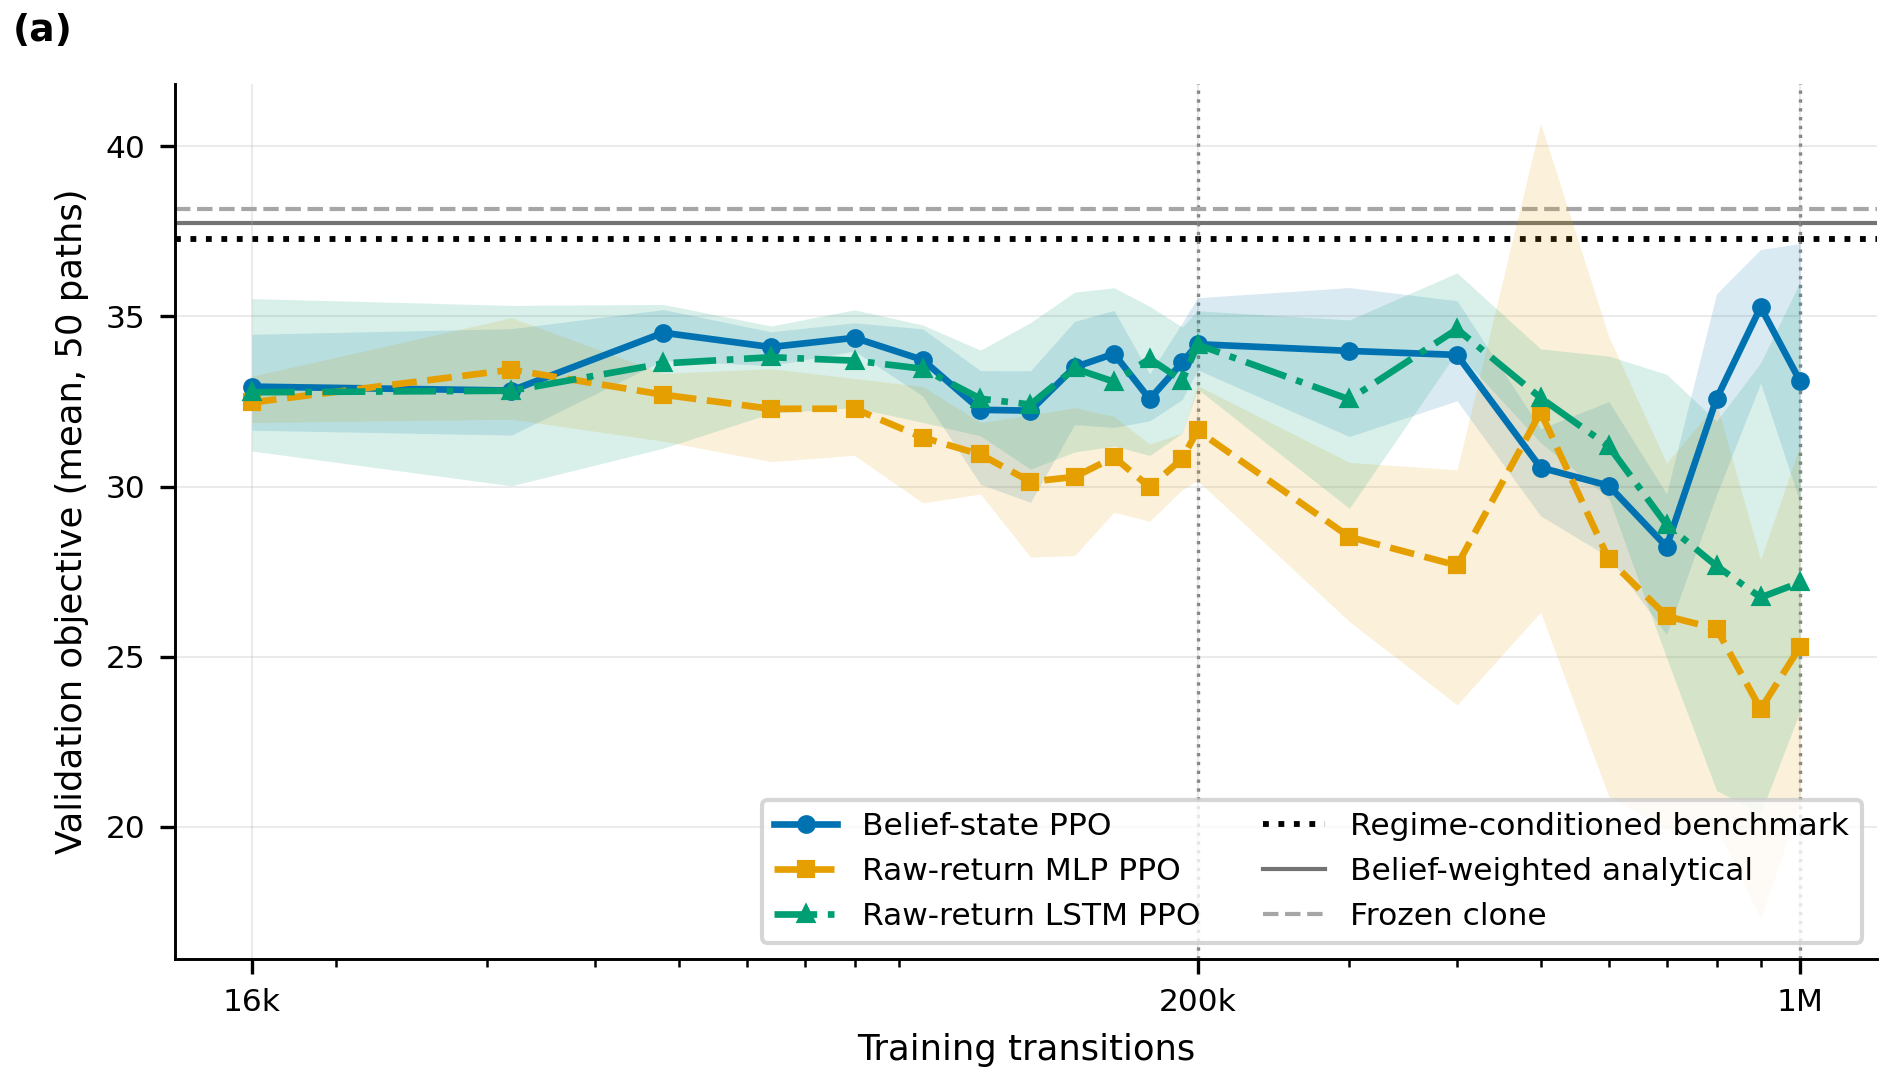

In [3]:
run("results/thesis_final_plots/fig01_learning_curves.py")
show("results/thesis_final_plots/figures/fig01_learning_curves.png")


## Holdout objective ECDF

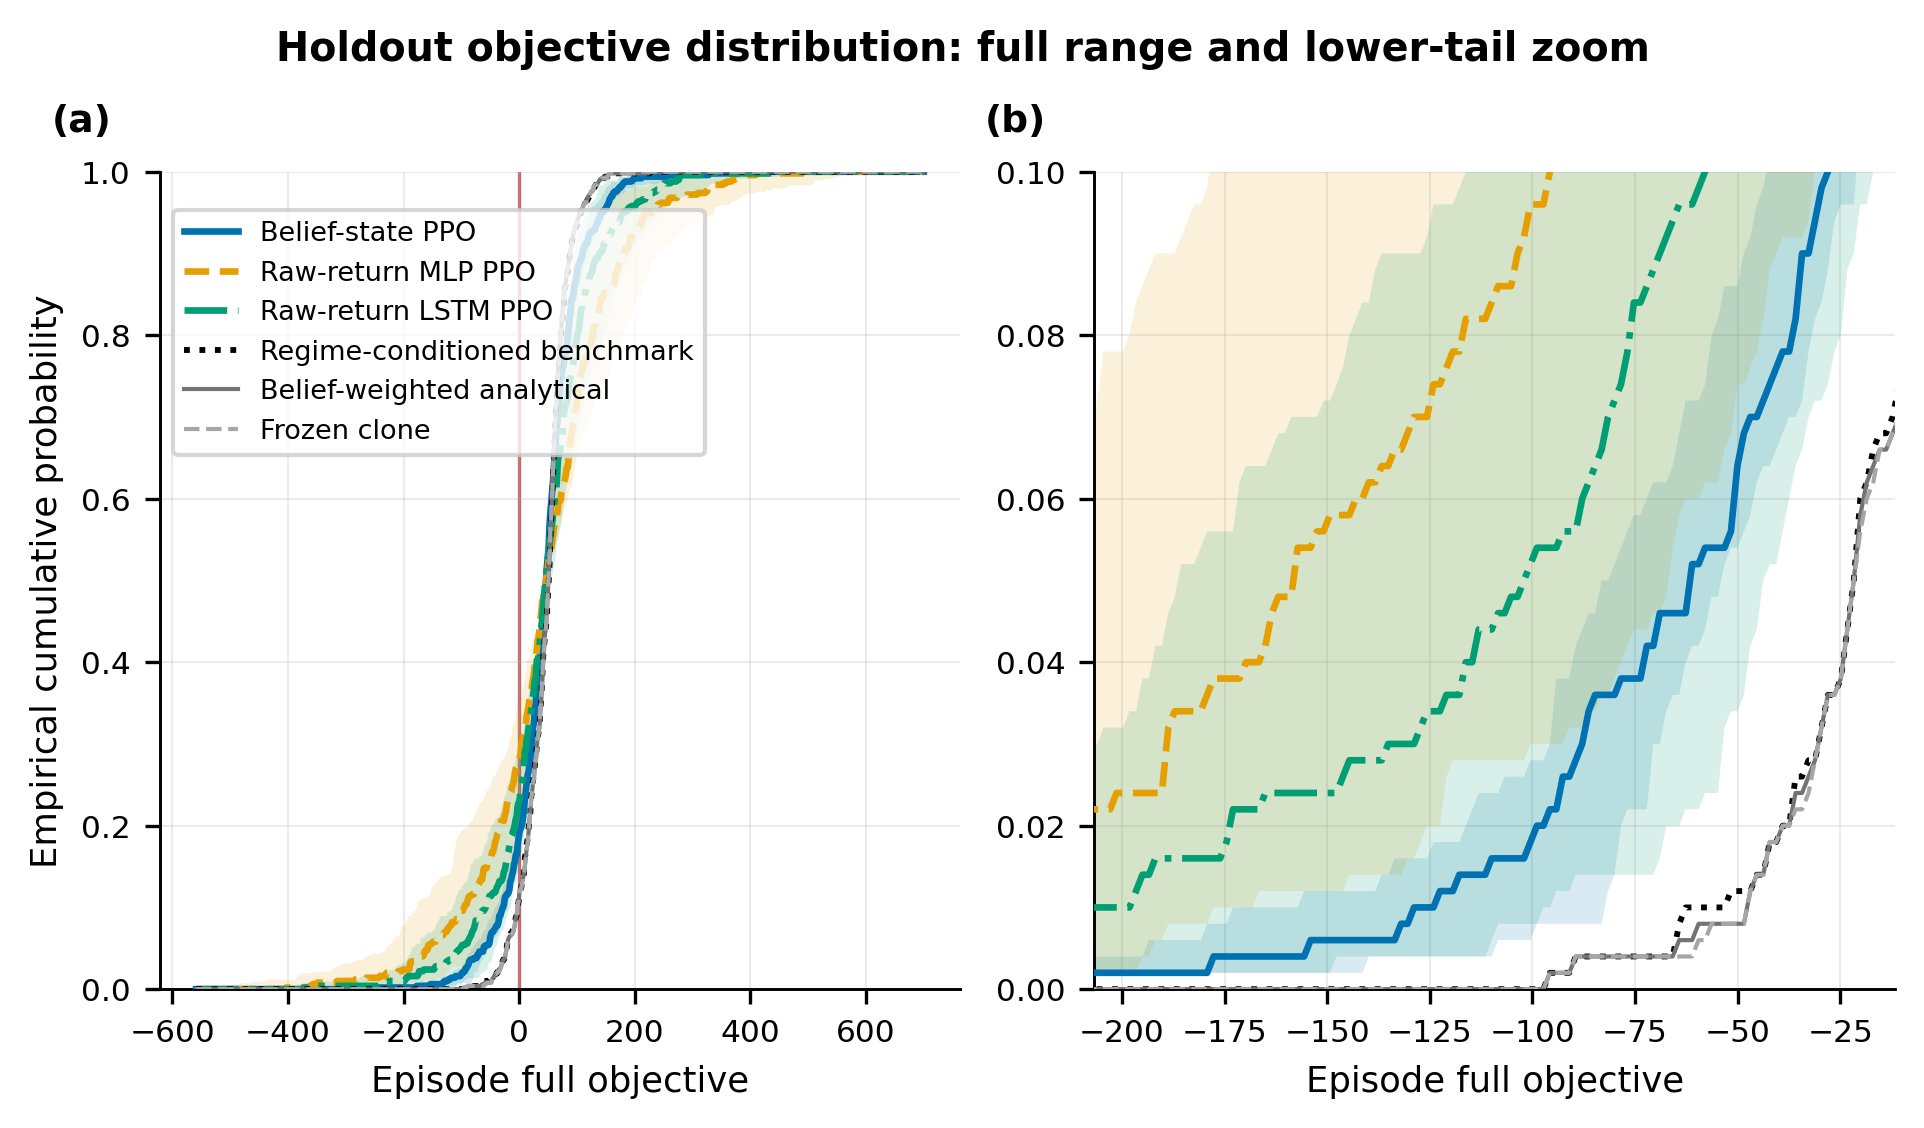

In [4]:
run("results/thesis_final_plots/fig02_holdout_ecdf.py")
show("results/thesis_final_plots/figures/fig02_holdout_ecdf.png")


## Paired forest vs. benchmarks

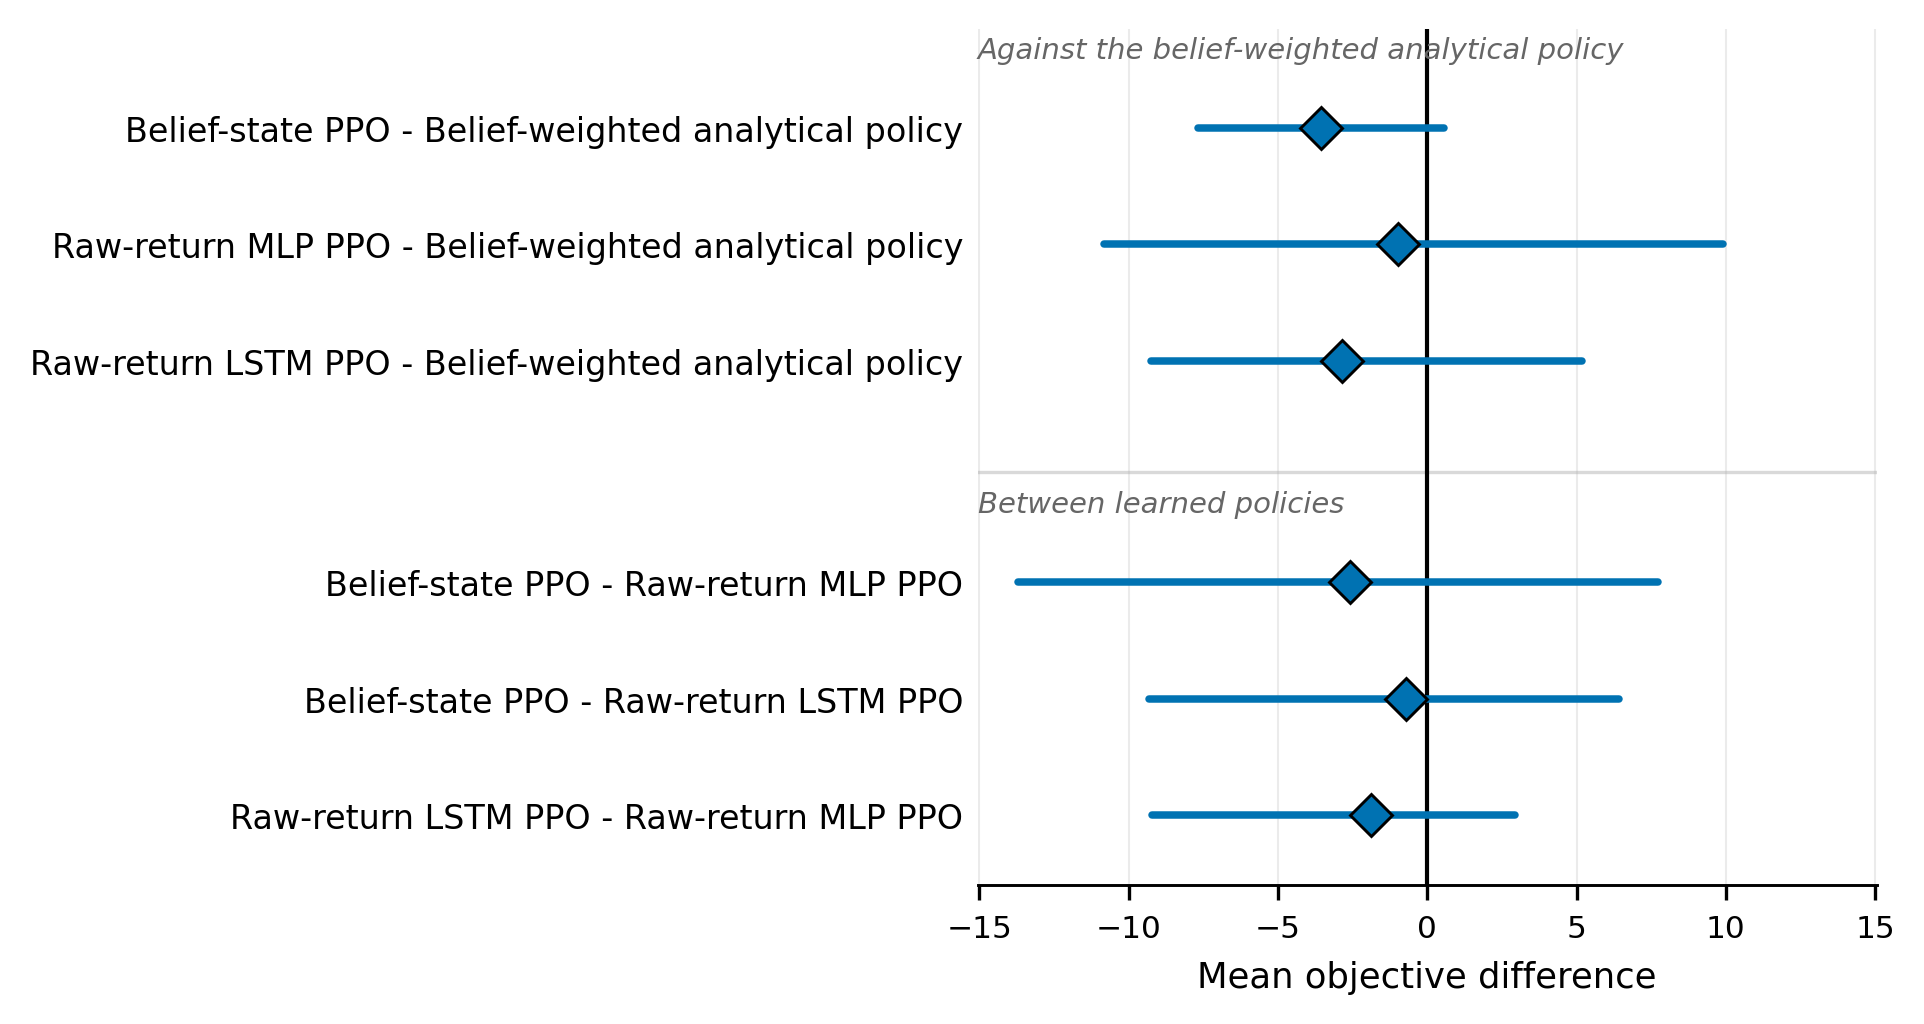

In [5]:
run("results/thesis_final_plots/fig03_paired_forest.py")
show("results/thesis_final_plots/figures/fig03_paired_forest.png")


## Risk-return

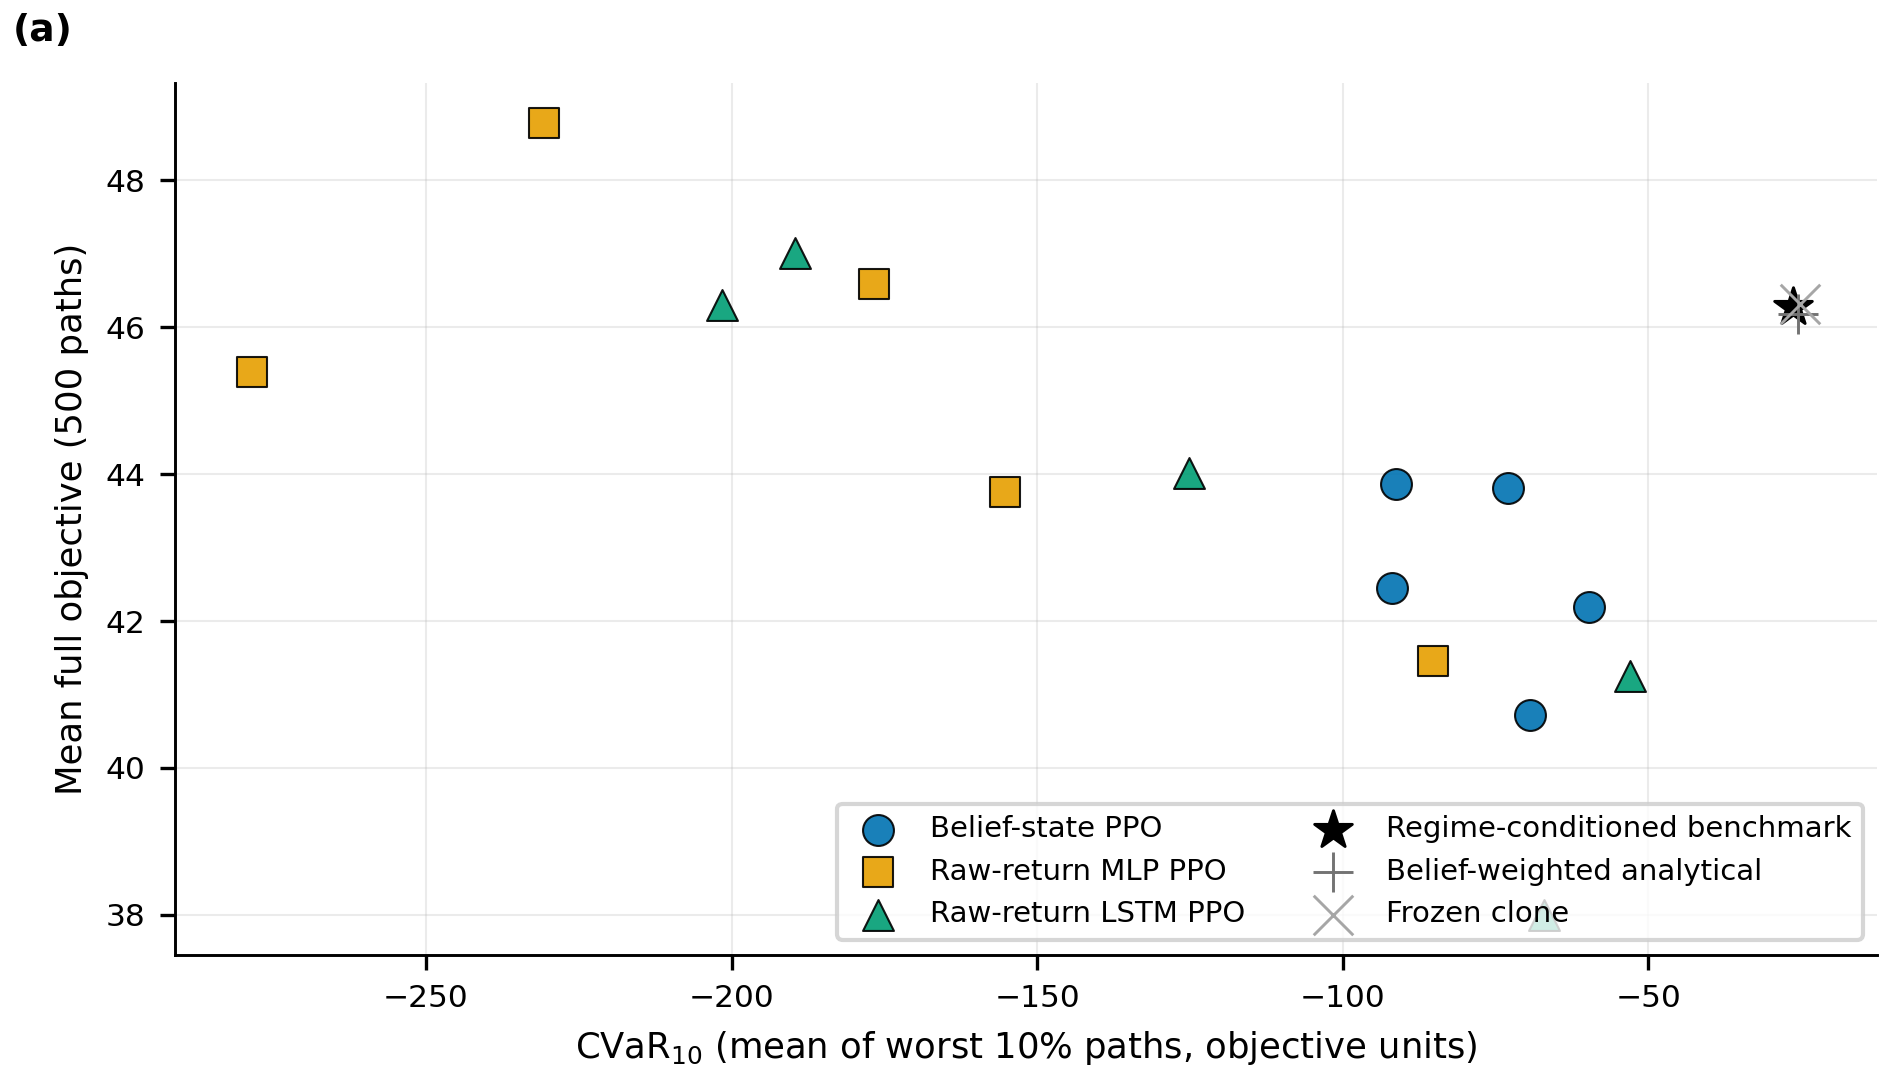

In [6]:
run("results/thesis_final_plots/fig05_risk_return.py")
show("results/thesis_final_plots/figures/fig05_risk_return.png")


## Signed and terminal inventory

In [7]:
seed_summary = pd.read_csv(RESULTS / "final_holdout_seed_summary.csv")
seed_sub = seed_summary[seed_summary["checkpoint_transition"] == 1_000_000]

rows = []
for arch, label in ARCH_LABELS.items():
    d = seed_sub[seed_sub["policy"] == arch]
    n = len(d)
    rows.append({
        "Policy": label,
        "Mean signed inventory": d["mean_mean_signed_inventory"].mean(),
        "SE": d["mean_mean_signed_inventory"].std(ddof=1) / np.sqrt(n),
        "Mean terminal inventory": d["mean_terminal_signed_inventory"].mean(),
        "SE ": d["mean_terminal_signed_inventory"].std(ddof=1) / np.sqrt(n),
    })
for pol, label in BENCH_LABELS.items():
    d = episode[episode["policy"] == pol]
    n = len(d)
    rows.append({
        "Policy": label,
        "Mean signed inventory": d["mean_signed_inventory"].mean(),
        "SE": d["mean_signed_inventory"].std(ddof=1) / np.sqrt(n),
        "Mean terminal inventory": d["terminal_signed_inventory"].mean(),
        "SE ": d["terminal_signed_inventory"].std(ddof=1) / np.sqrt(n),
    })
table2 = pd.DataFrame(rows).round(3)
table2


,Policy,Mean signed inventory,SE,Mean terminal inventory,SE
0,Belief-state PPO,1.060,0.581,1.602,1.178
1,Raw-return MLP PPO,-8.929,1.656,-15.346,3.873
2,Raw-return LSTM PPO,-5.742,2.182,-8.614,3.649
3,Regime-conditioned benchmark,0.139,0.140,0.148,0.257
4,Belief-weighted analytical policy,0.145,0.140,0.156,0.257
5,Frozen supervised clone,0.123,0.140,0.124,0.256


## Trajectory mechanism

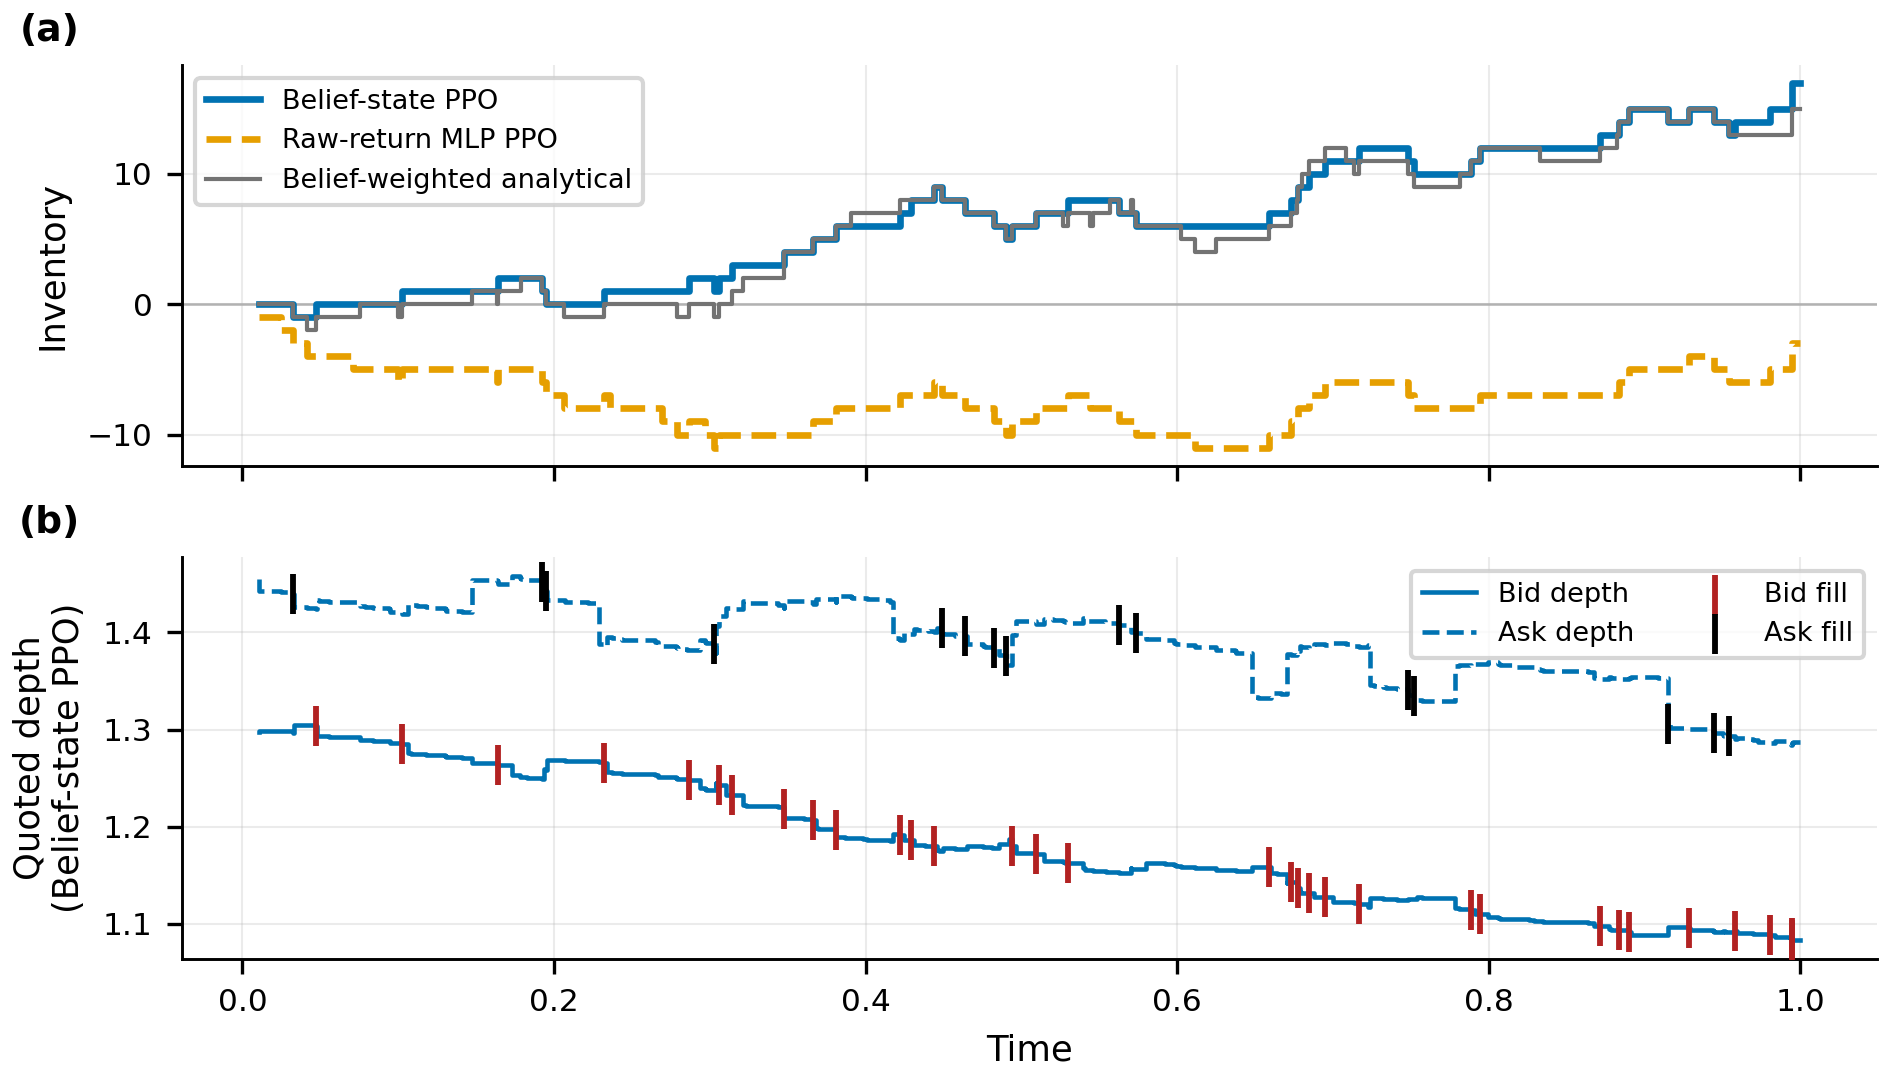

In [8]:
run("results/thesis_final_plots/fig06_trajectory_mechanism.py")
show("results/thesis_final_plots/figures/fig06_trajectory_mechanism.png")


## Behavioural metrics vs. training budget

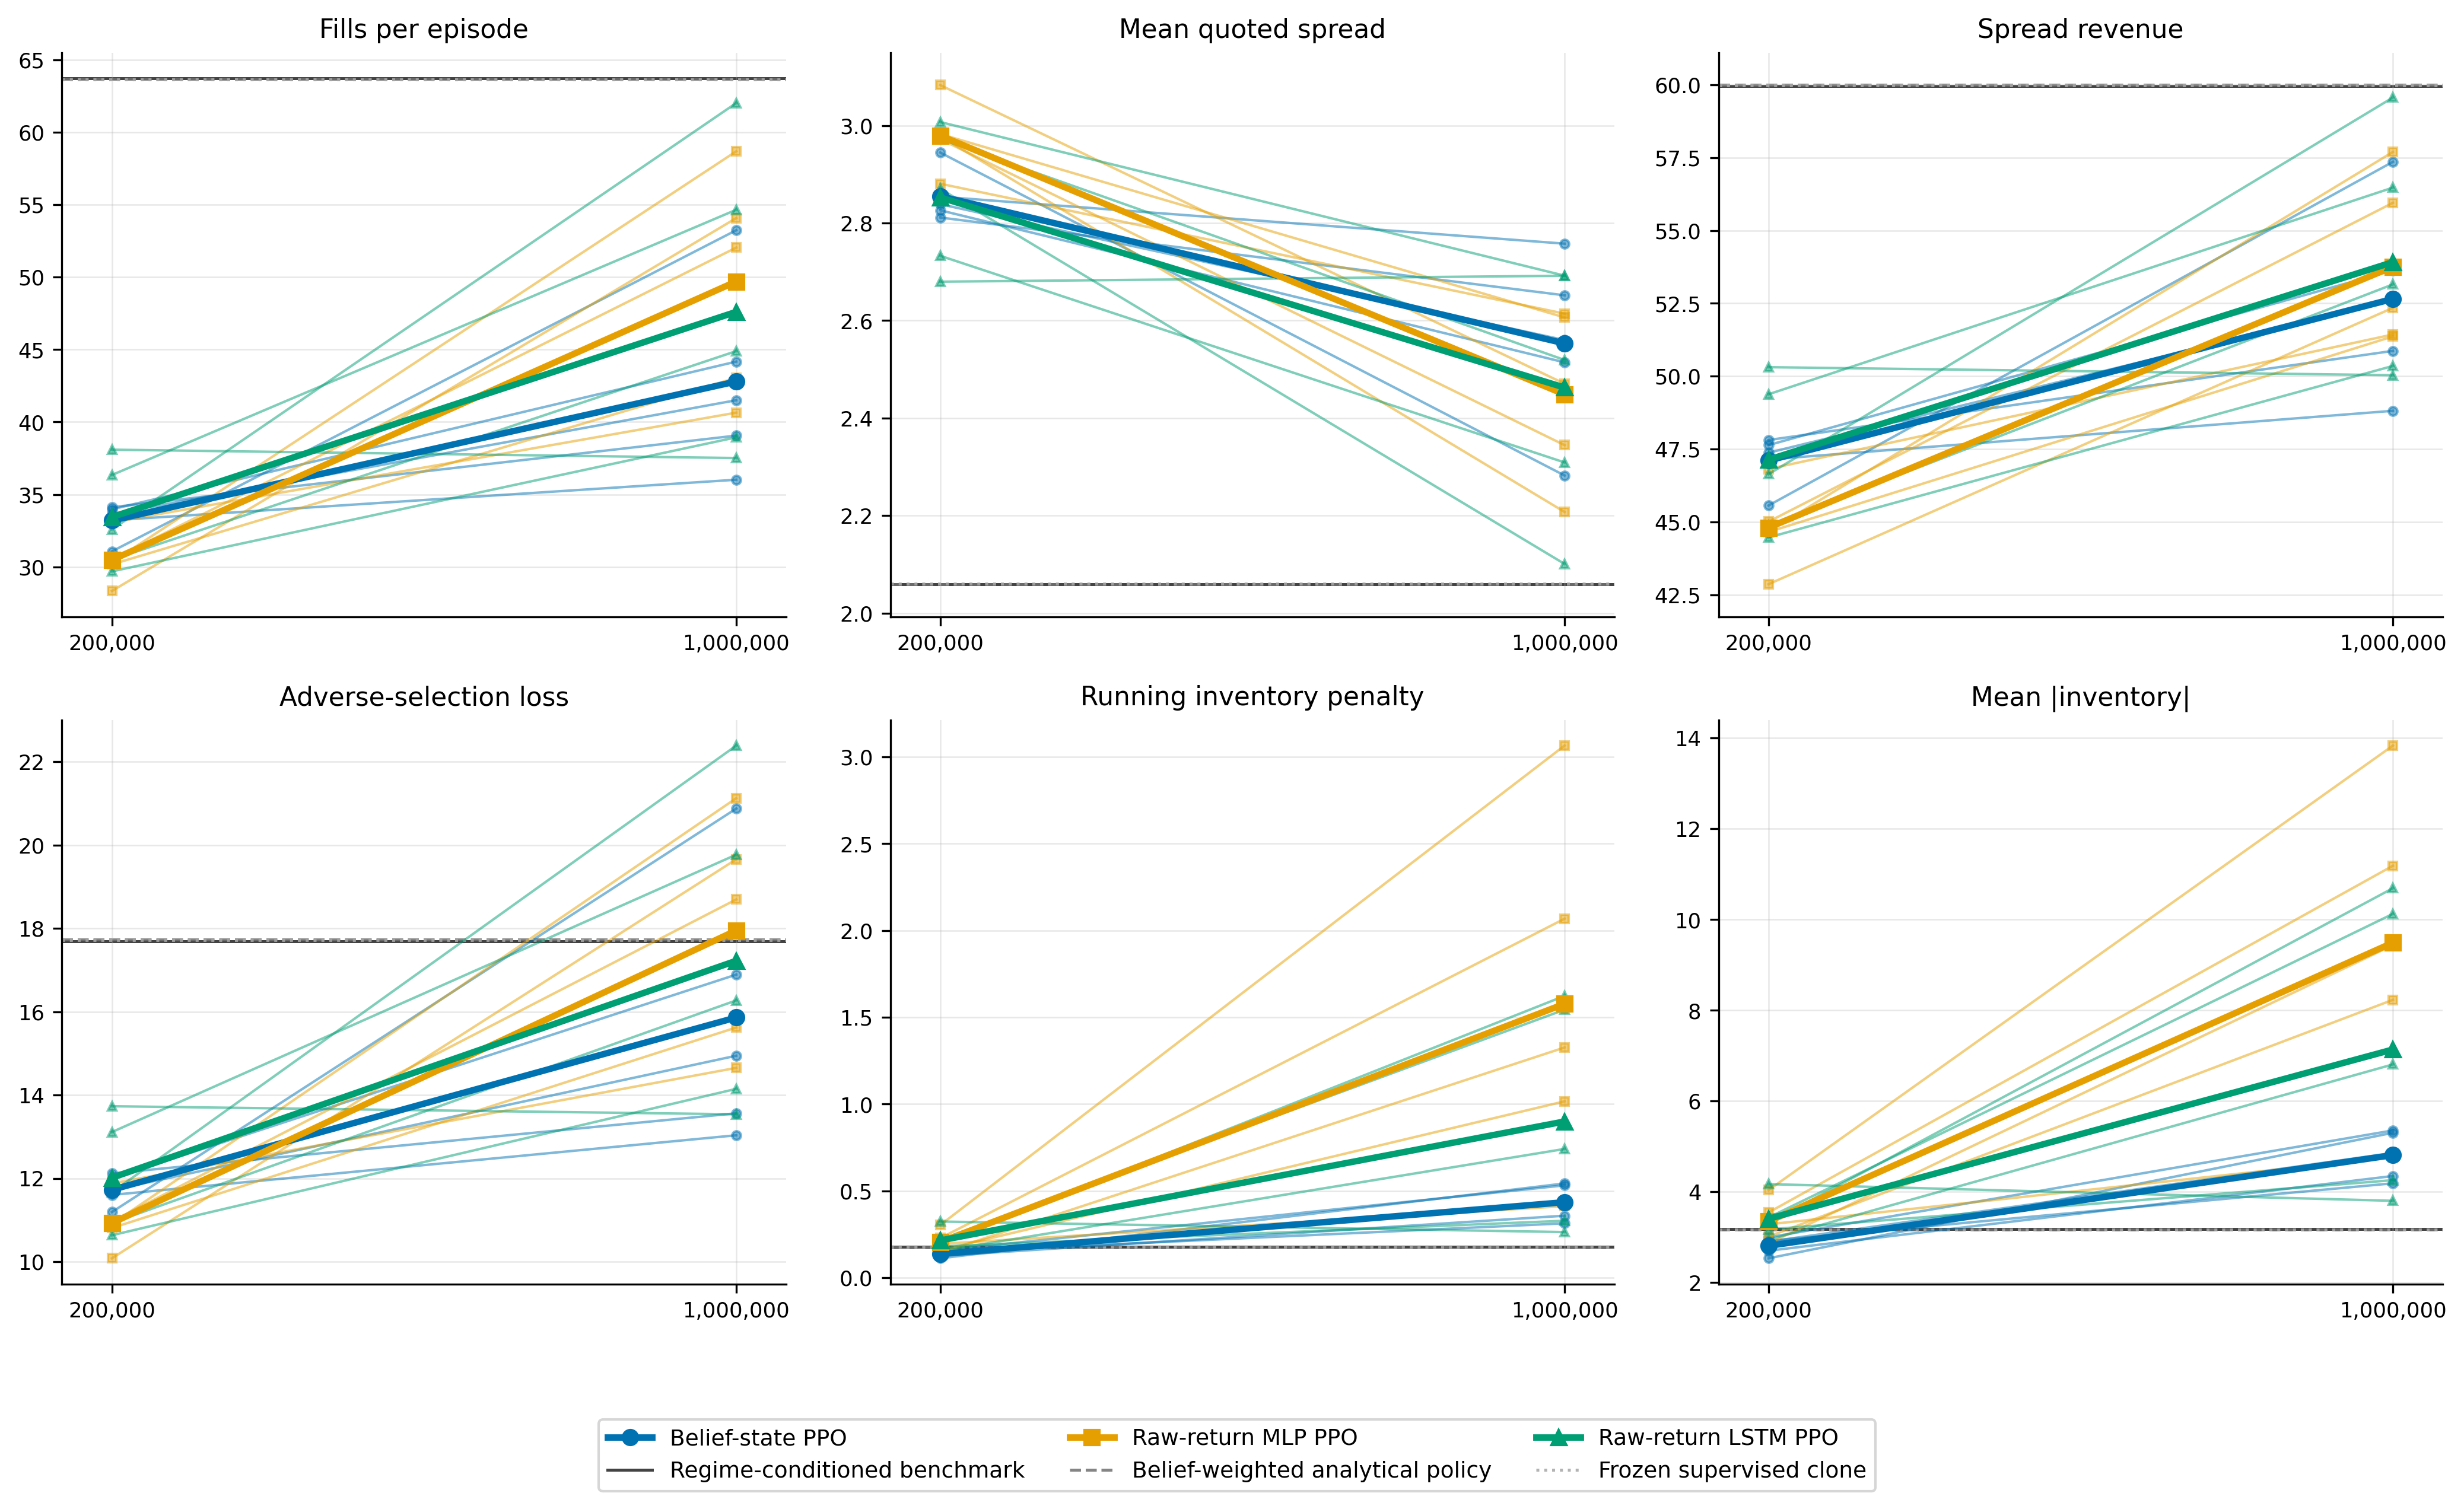

In [9]:
run("results/thesis_final_plots/06_behavioral_metrics_budget_slope.py")
show("results/thesis_final_plots/figures/06_behavioral_metrics_budget_slope.png")


## PPO training diagnostics

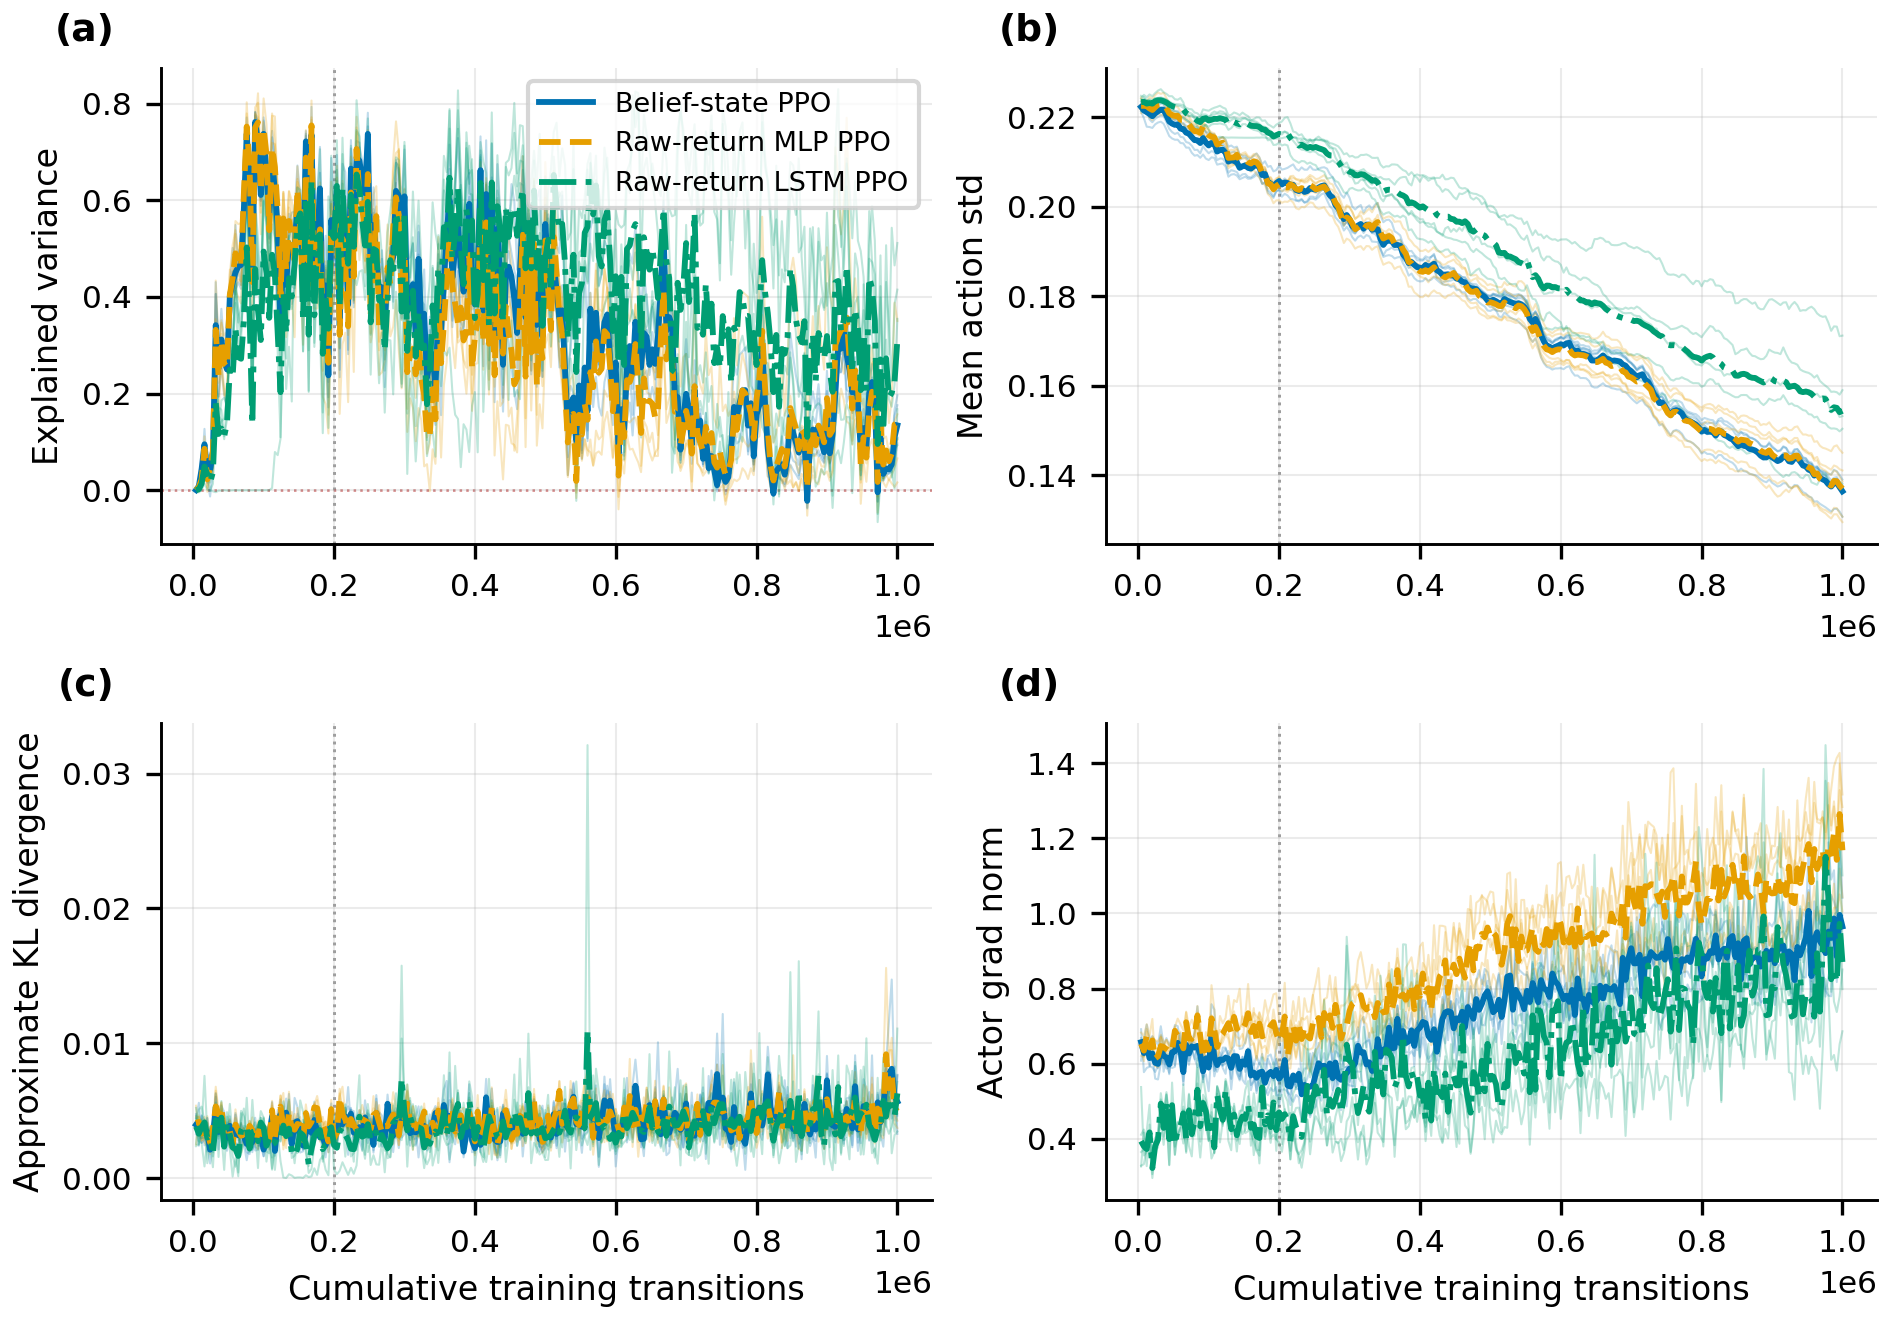

In [10]:
run("results/thesis_final_plots/figA2_ppo_diagnostics.py")
show("results/thesis_final_plots/figures/figA2_ppo_diagnostics.png")


## Midprice path

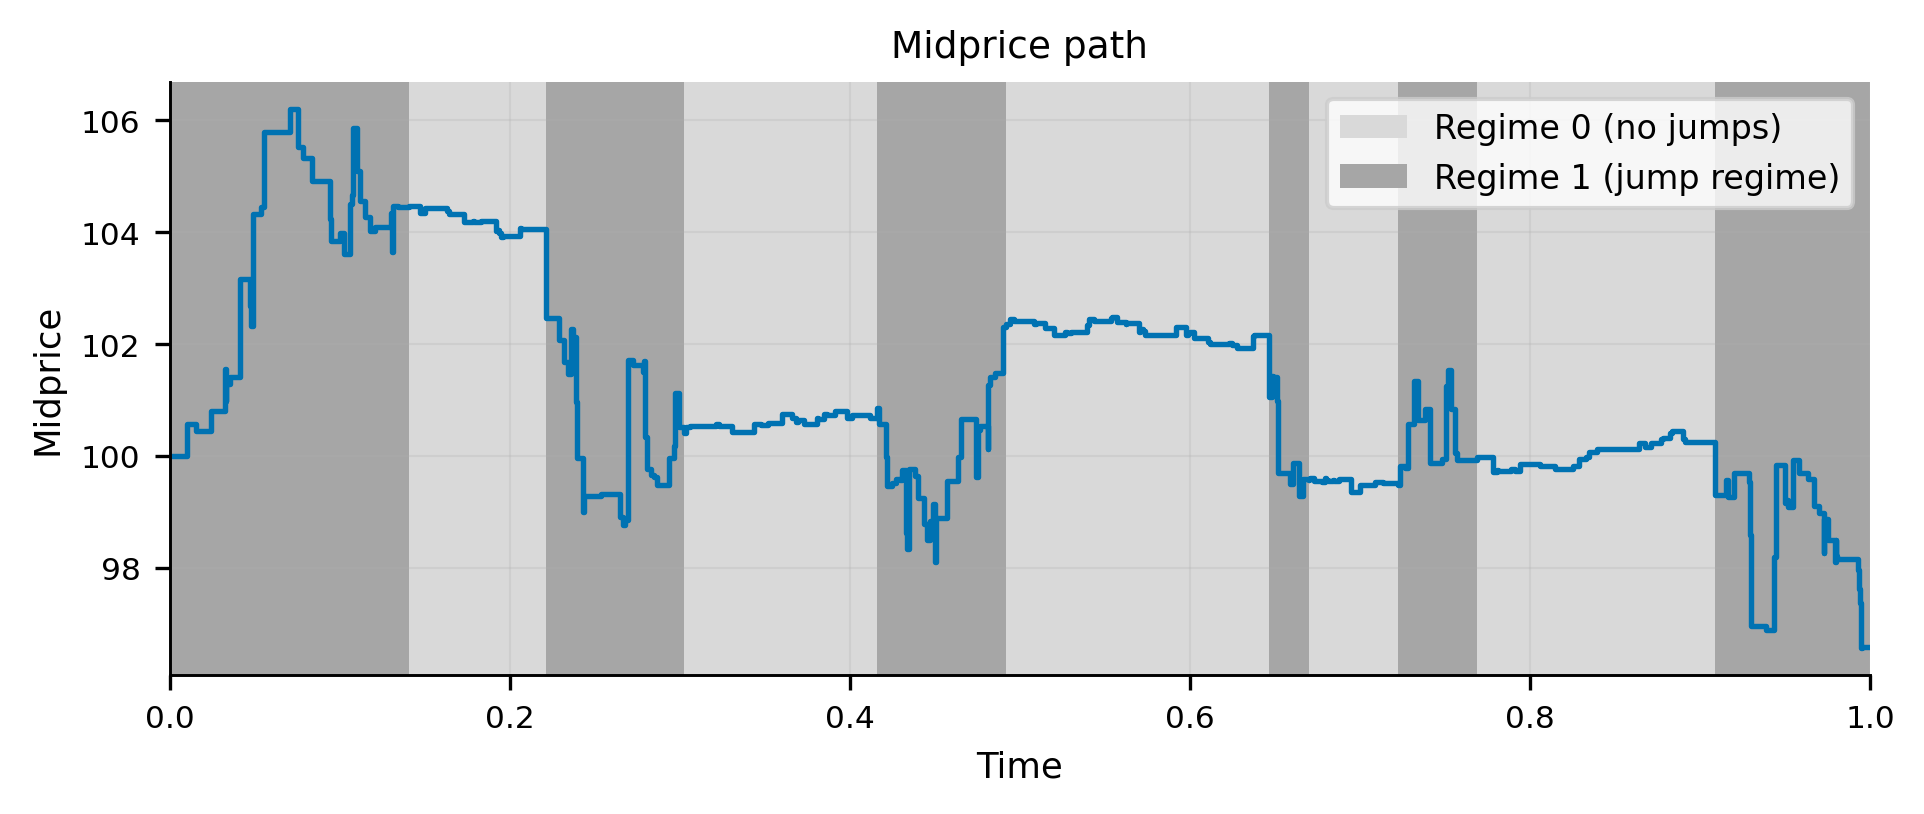

In [11]:
run("results/thesis_final_plots/plot_midprice_path.py")
show("results/thesis_final_plots/figures/midprice_path.png")


## Filter calibration

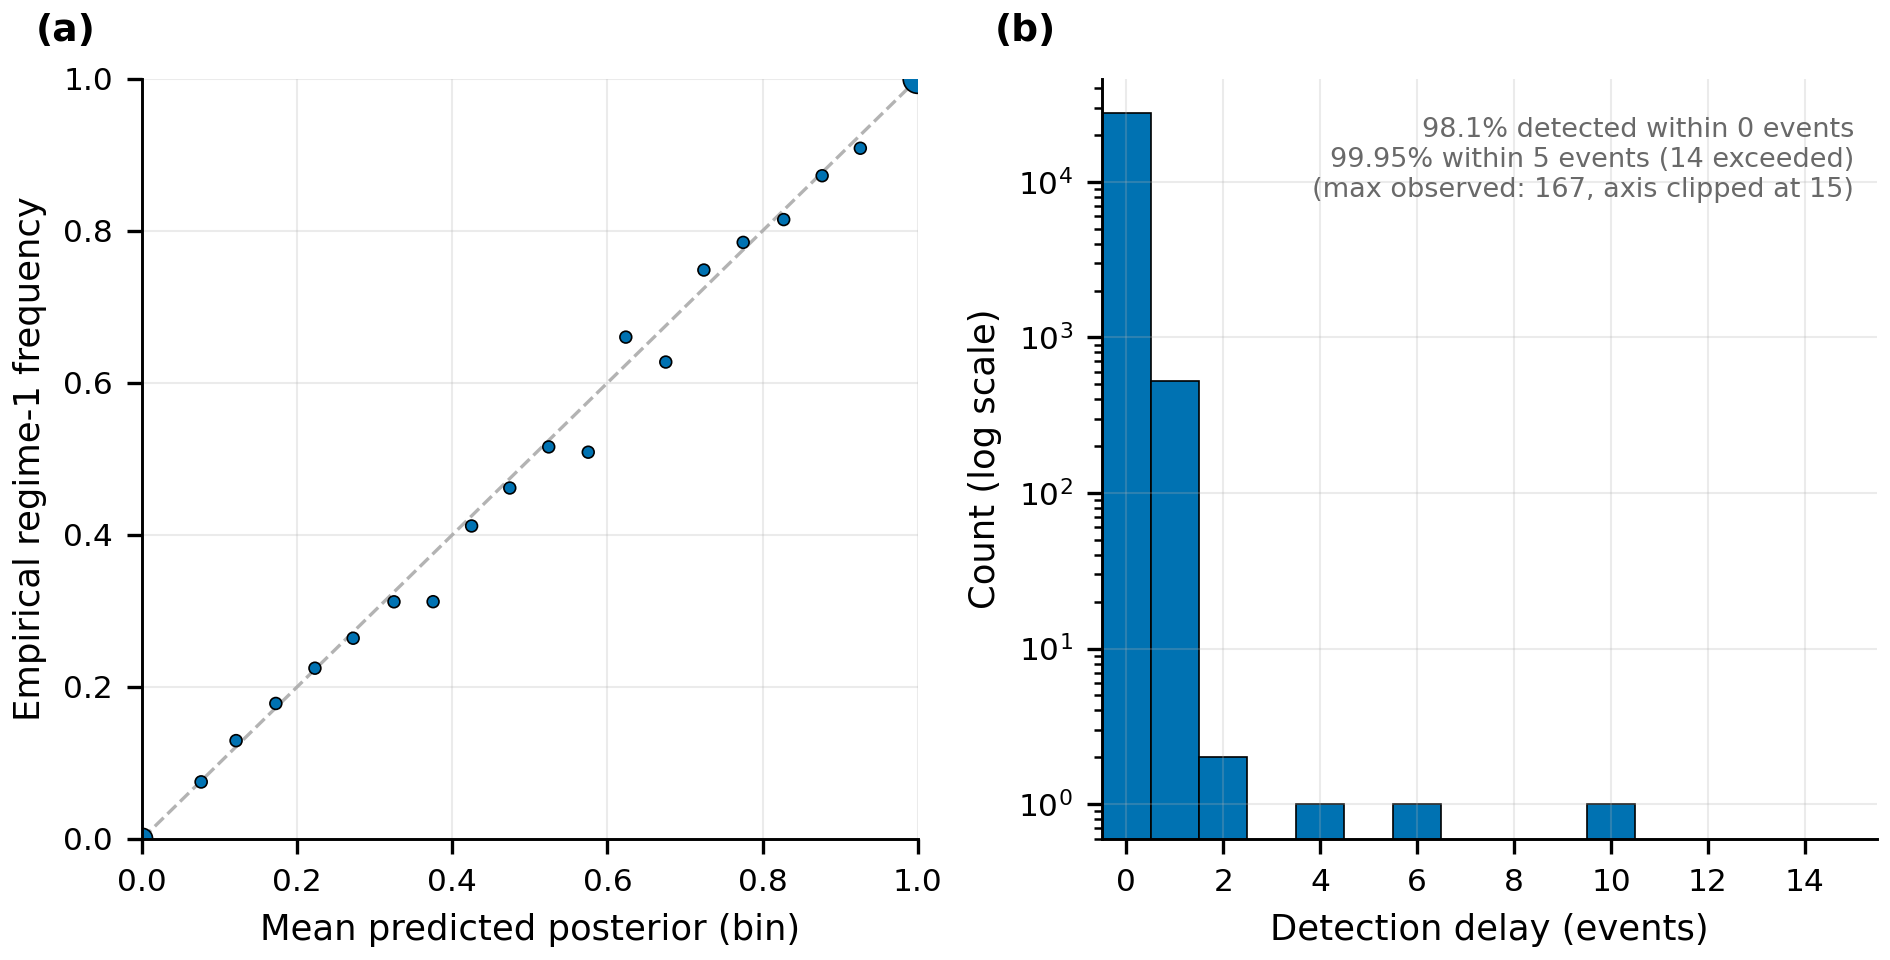

In [12]:
run("results/thesis_final_plots/figA1_filter_calibration.py")
show("results/thesis_final_plots/figures/figA1_filter_calibration.png")


## Epsilon sweep / detection delay

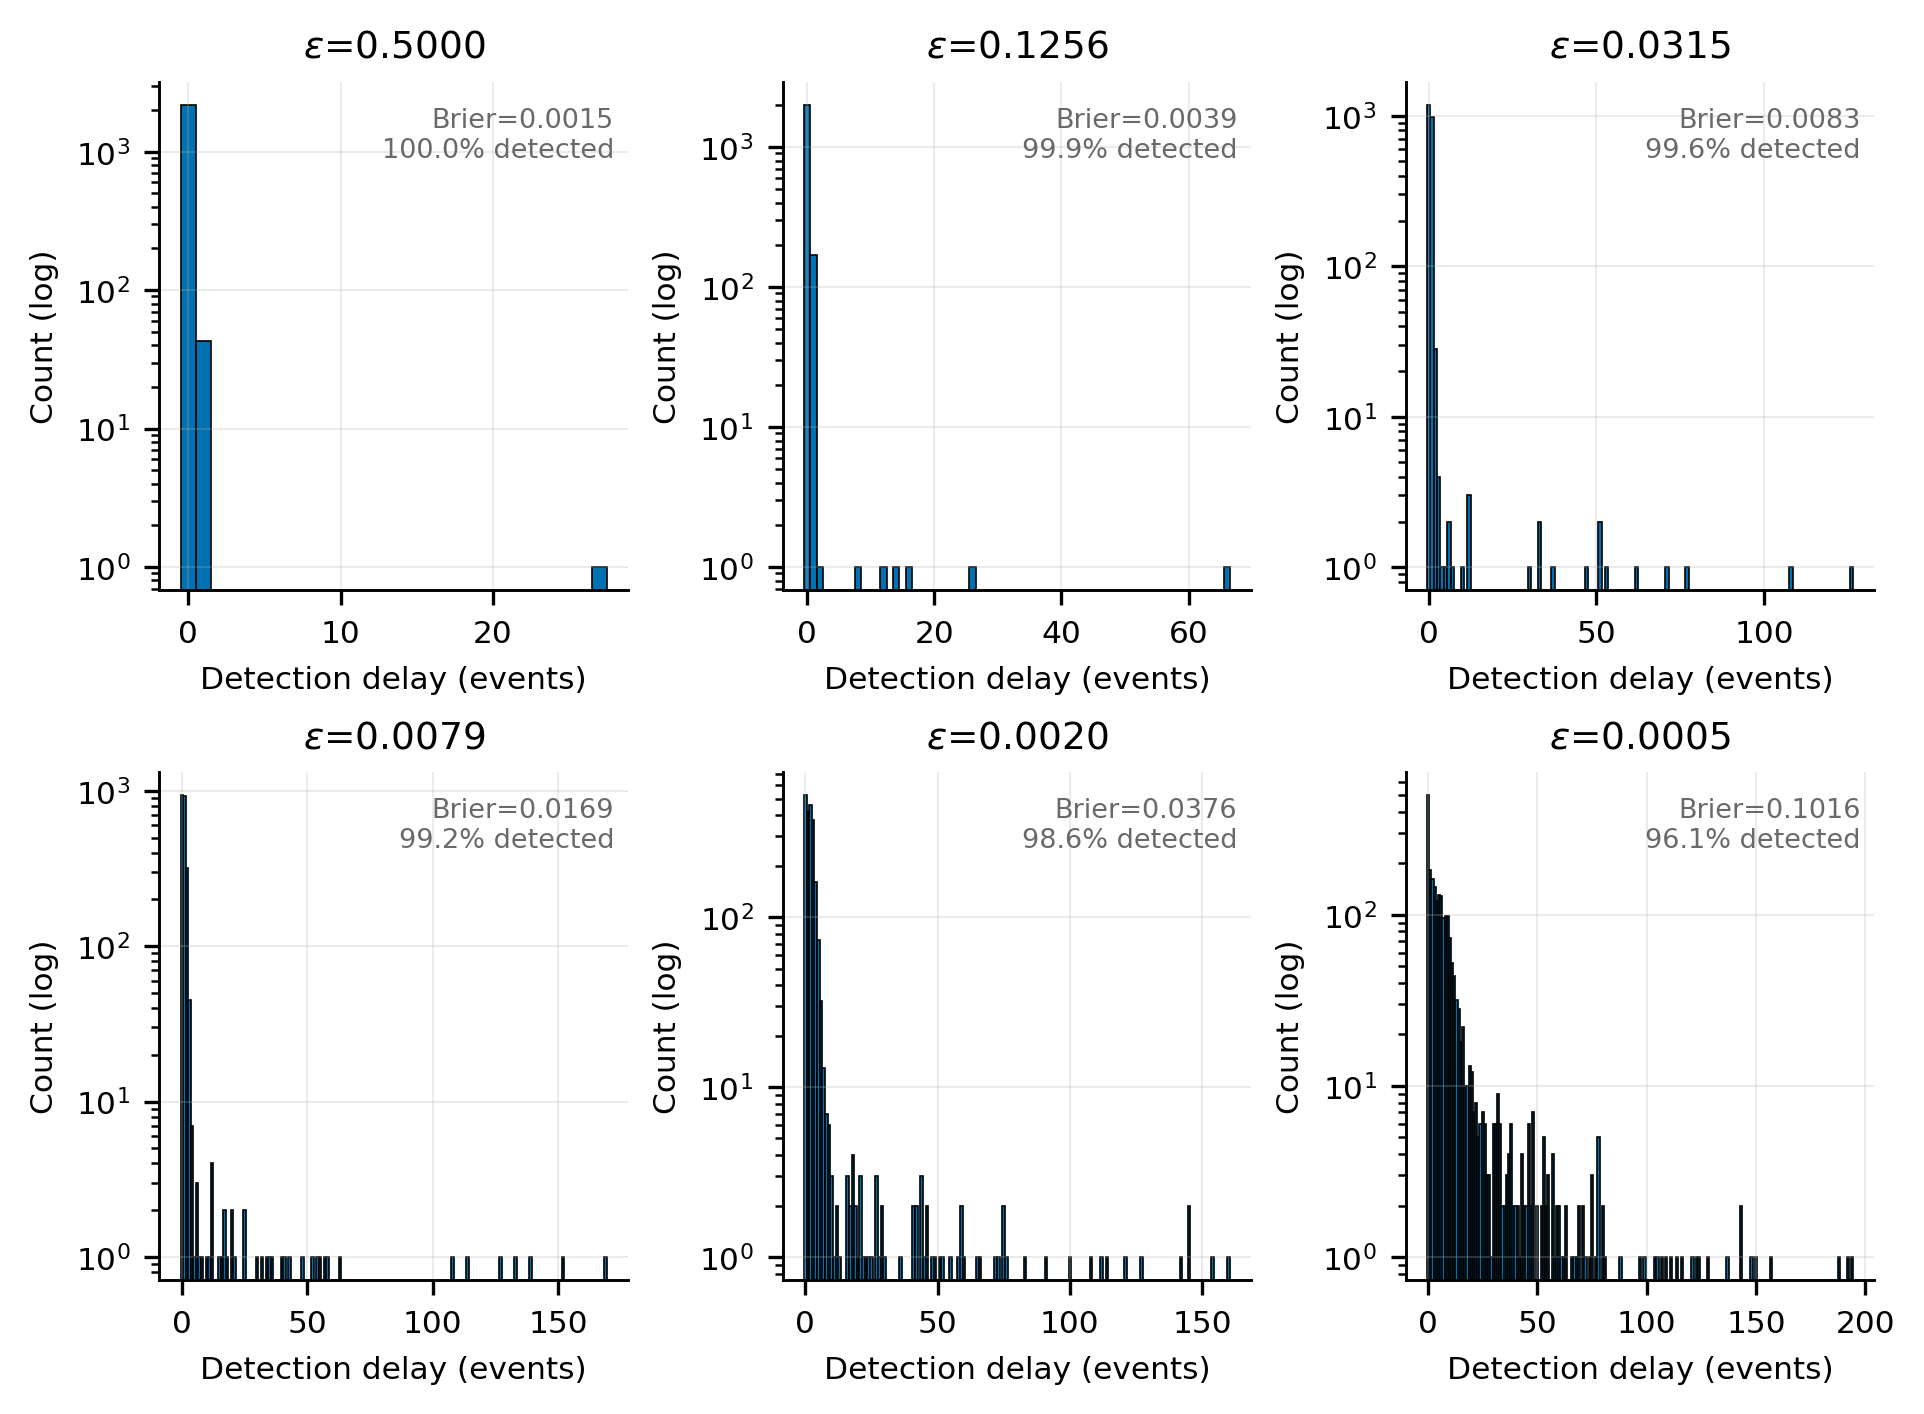

In [13]:
run("results/thesis_final_plots/build_epsilon_sweep_detection_delay.py")
show("results/thesis_final_plots/figures/fig_epsilon_sweep_detection_delay.png")


## Belief vs. regime (synthetic)

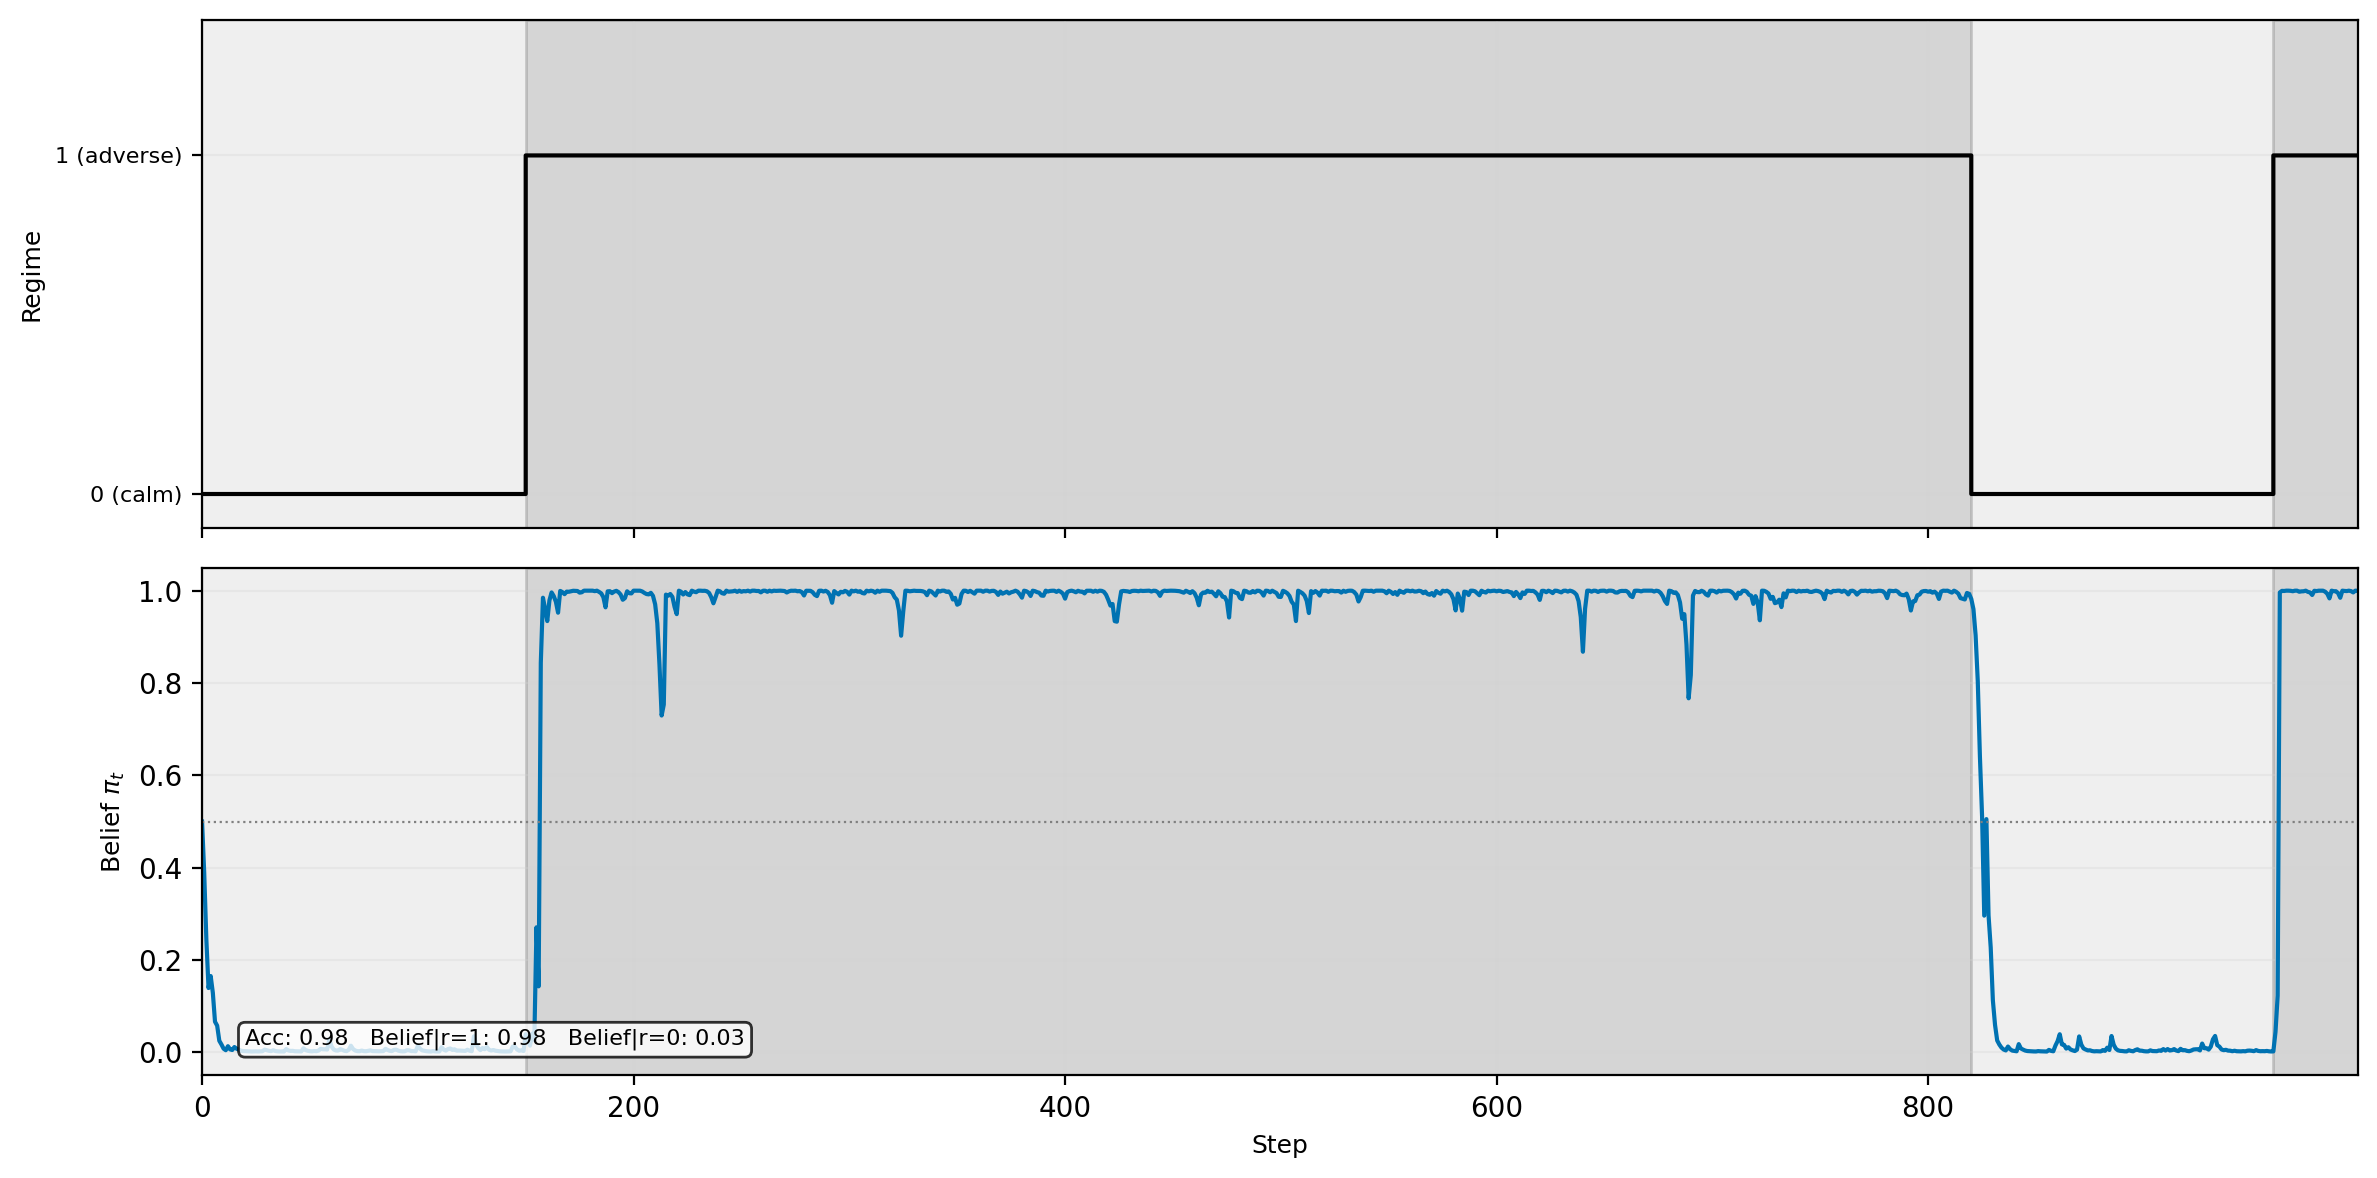

In [14]:
run("diagnostics/plot_belief_vs_regime_synthetic.py")
show_latest("belief_vs_regime_synthetic_*.png")


## Filter diagnostic (Case A / Case B)

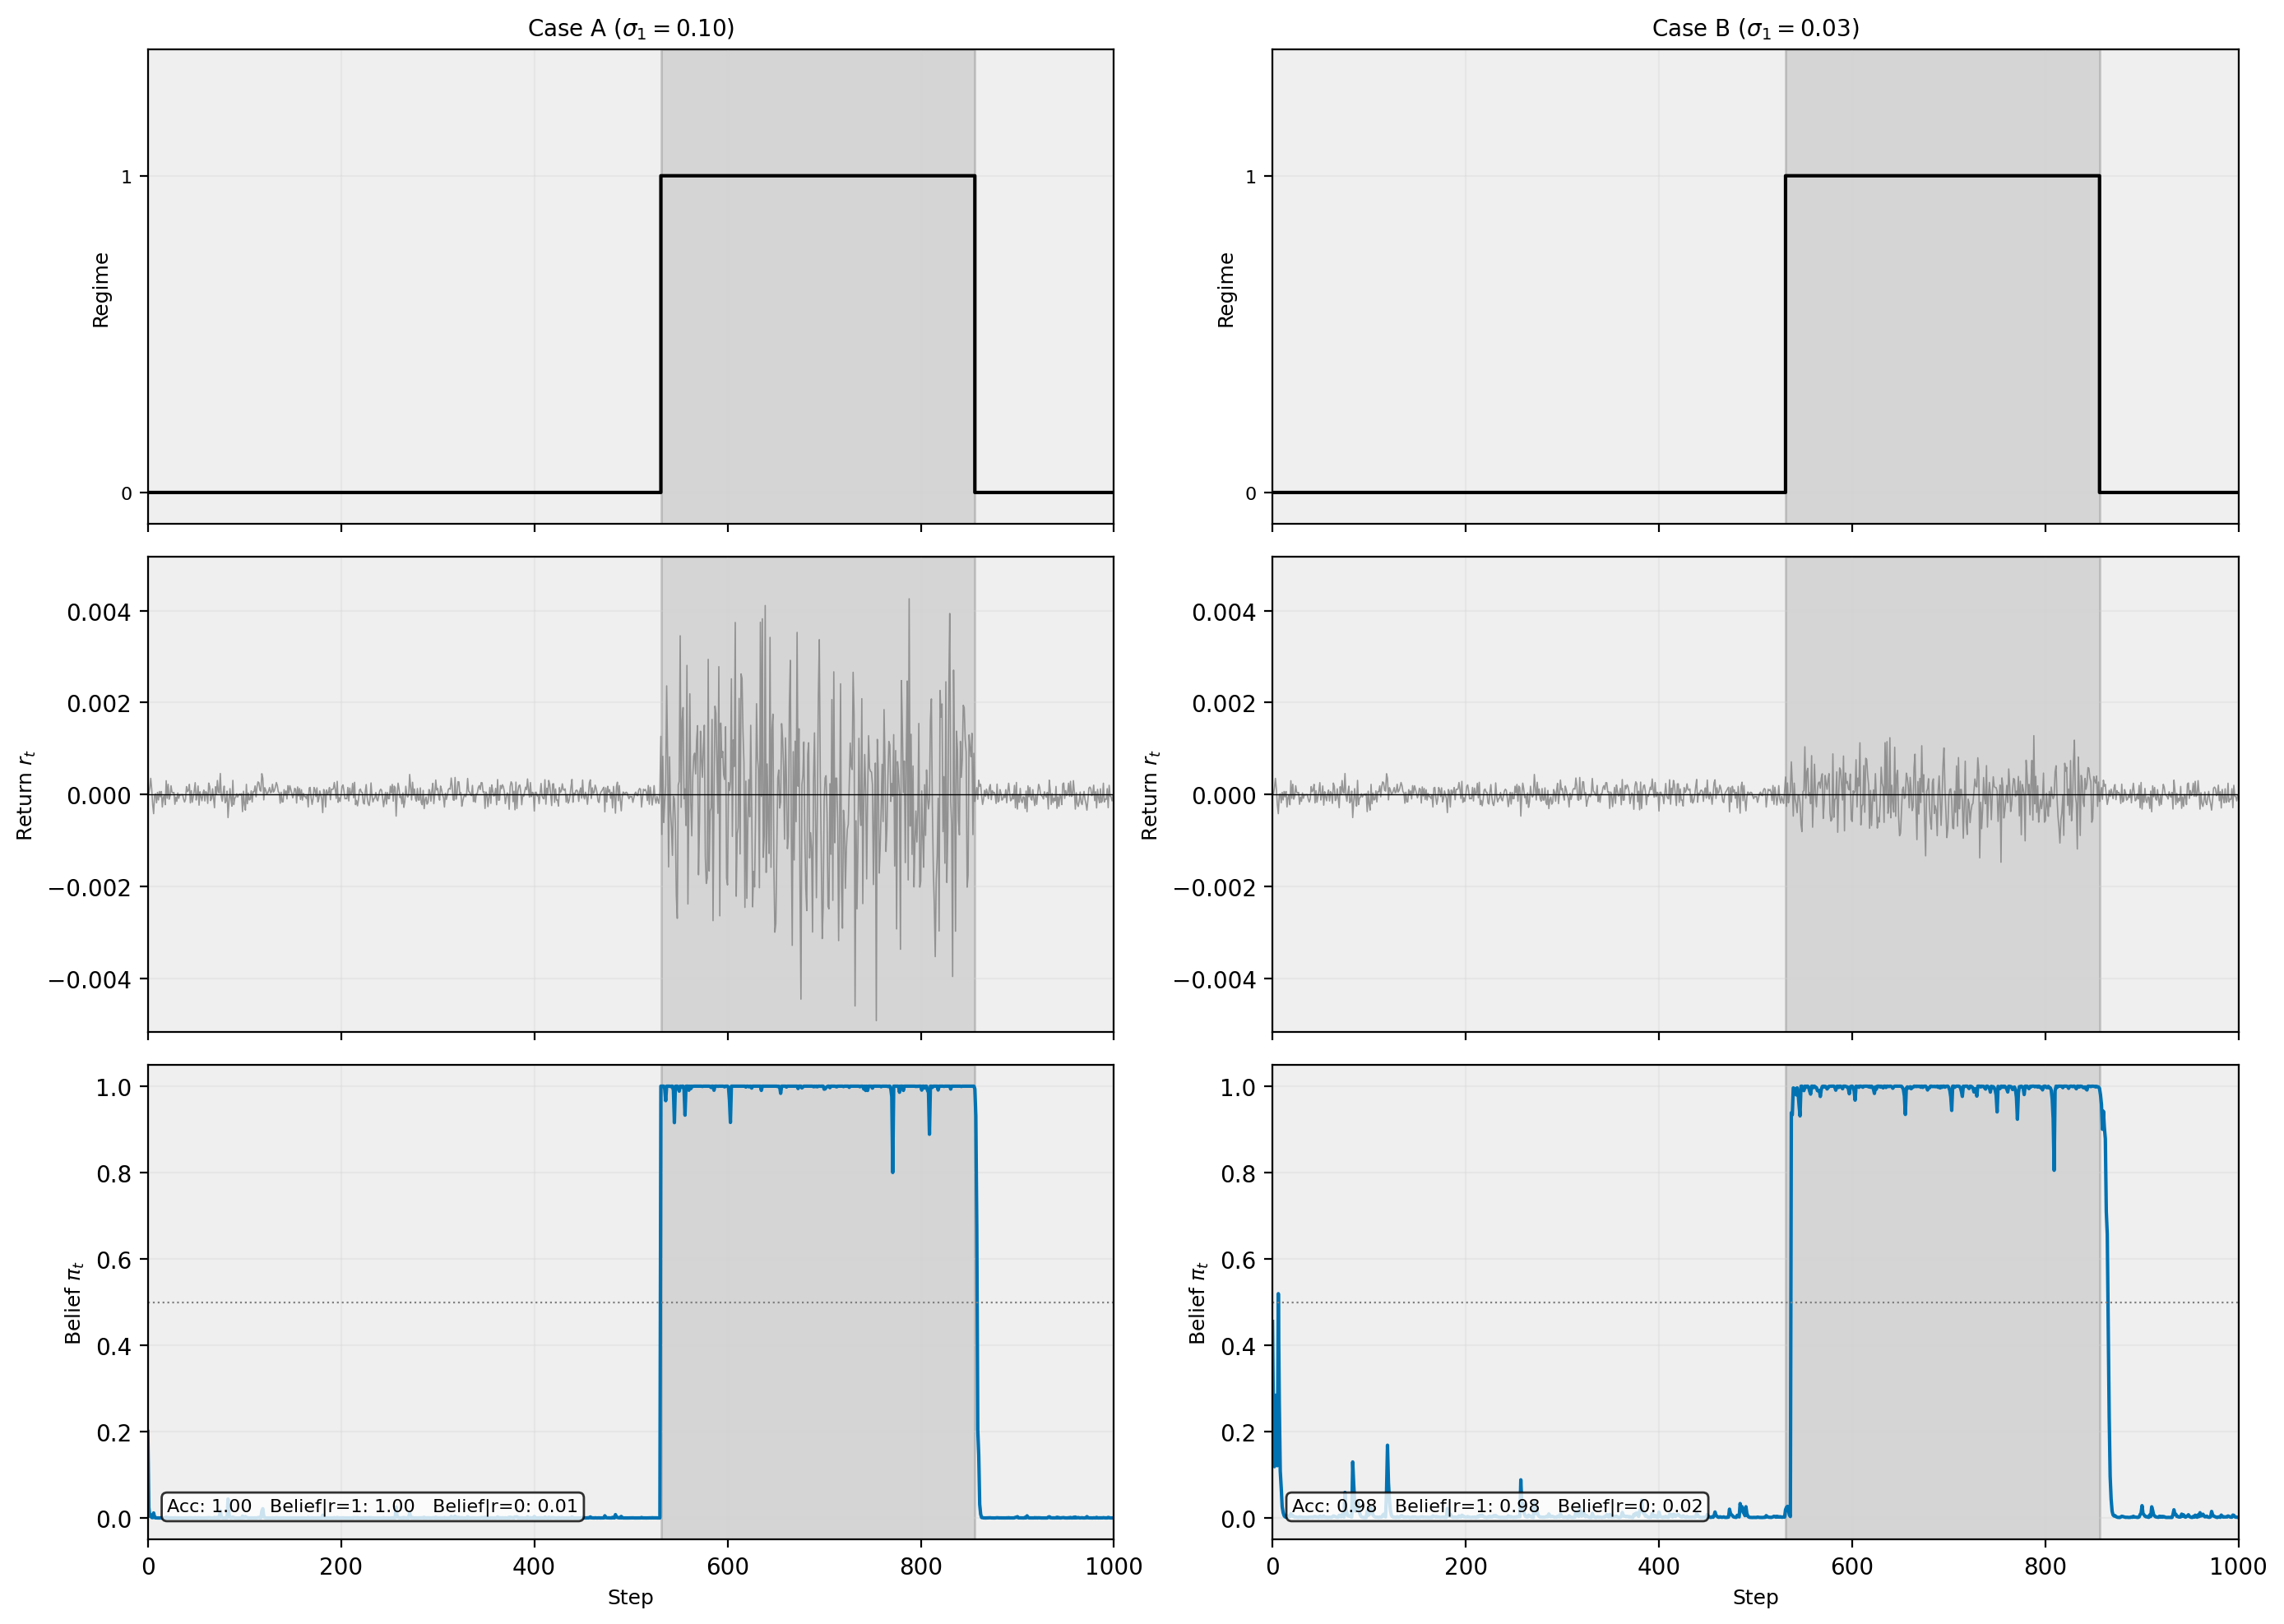

In [15]:
run("diagnostics/diagnostic_filter_case_a.py")
show_latest("filter_diagnostic_r0_*.png")


## Inventory under two penalty calibrations

In [16]:
IPS_RESULTS = REPO_ROOT / "results" / "inventory_penalty_sensitivity"
policy_summary = pd.read_csv(IPS_RESULTS / "policy_summary.csv")

rows = []
for arch, label in ARCH_LABELS.items():
    o = policy_summary[(policy_summary["policy"] == arch) & (policy_summary["penalty_calibration"] == "original")].iloc[0]
    h = policy_summary[(policy_summary["policy"] == arch) & (policy_summary["penalty_calibration"] == "high_penalty")].iloc[0]
    rows.append({
        "Policy": label,
        "Mean signed inventory": f"{o['cross_seed_mean_mean_signed_inventory_event_weighted']:.3f} -> "
                                  f"{h['cross_seed_mean_mean_signed_inventory_event_weighted']:.3f}",
        "Mean |Q|": f"{o['cross_seed_mean_mean_abs_inventory_event_weighted']:.3f} -> "
                    f"{h['cross_seed_mean_mean_abs_inventory_event_weighted']:.3f}",
        "Mean |Q_T|": f"{o['cross_seed_mean_abs_terminal_inventory']:.3f} -> "
                      f"{h['cross_seed_mean_abs_terminal_inventory']:.3f}",
    })
table3 = pd.DataFrame(rows)
table3


,Policy,Mean signed inventory,Mean |Q|,Mean |Q_T|
0,Belief-state PPO,1.060 -> 2.411,4.809 -> 4.236,9.096 -> 6.073
1,Raw-return MLP PPO,-8.929 -> -0.024,9.491 -> 5.061,16.135 -> 7.840
2,Raw-return LSTM PPO,-5.742 -> 0.484,7.137 -> 4.504,11.043 -> 7.606
